In [ ]:
#title : 'Fitting a logistic regression model for the probability of diverted US flights'
#author : Vishma Arachchi
#date : 2024-02-06
#purpose : A script to predict if a particular flight was diverted or not.




In [1]:
#IMPORTING LIBRARIES

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml #using openml to import data
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer 
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix



In [2]:
#IMPORTING DATASETS

df_main = pd.read_csv("/Users/vishmaarachchi/Documents/BSC/Programming coursework - PROJECT/2006.csv.bz2")
airport_df = pd.read_csv('/Users/vishmaarachchi/Documents/BSC/Programming coursework - PROJECT/airports.csv')

In [3]:
#RENAMING COLUMNS

airport_df.rename(columns={'iata': 'Dest'}, inplace=True)

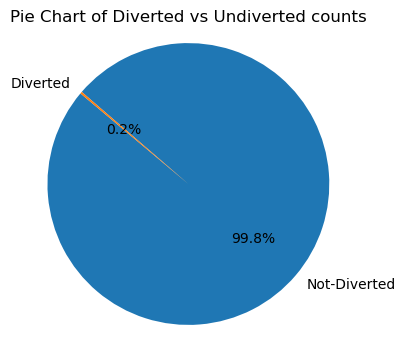

In [4]:
#NOTICING LARGE IMBALANCE IN TARGET VARIABLE(DIVERTED OR UNDIVERTED)


diverted_counts = df_main['Diverted'].value_counts()
diverted_counts

plt.figure(figsize=(4, 4))
custom_labels = ['Not-Diverted', 'Diverted']
plt.pie(diverted_counts, labels = custom_labels, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of Diverted vs Undiverted counts')
plt.axis('equal')  
plt.show()


In [5]:
#Merging airport and main dataset and filtering out unncessary features

dff_1 = pd.merge(df_main, airport_df, on='Dest', how='left')
df_test = dff_1[['Month','Dest', 'Origin','lat','long','DayOfWeek', 'CRSDepTime', 'CRSArrTime','UniqueCarrier','Distance','Diverted']]
df_test.rename(columns={'lat': 'Destination_Latitude'}, inplace=True)
df_test.rename(columns={'long': 'Destination_Longitude'}, inplace=True)

airport_df['Origin'] = airport_df['Dest'].copy()
df_test = pd.merge(df_test, airport_df, on='Origin', how='left')

df_test.rename(columns={'lat': 'Origin_Latitude'}, inplace=True)
df_test.rename(columns={'long': 'Origin_Longitude'}, inplace=True)

df_test.drop(columns=['state','Dest_y','airport','city','country','Dest_x','Origin'], inplace=True)


/var/folders/yp/w9t80bwn7wq66cg1_srgxg3h0000gn/T/ipykernel_41299/800302435.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.rename(columns={'lat': 'Destination_Latitude'}, inplace=True)
/var/folders/yp/w9t80bwn7wq66cg1_srgxg3h0000gn/T/ipykernel_41299/800302435.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.rename(columns={'long': 'Destination_Longitude'}, inplace=True)


In [6]:
#mapping month and day of the week to strings and converting all categorical variables to type category

month_map = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sep',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}


df_test['Month'] = df_test['Month'].map(month_map)
df_test['Month'] = df_test['Month'].astype('category')

day_map = {
    1: 'Mon',
    2: 'Tue',
    3: 'Wed',
    4: 'Thur',
    5: 'Fri',
    6: 'Sat',
    7: 'Sun',
}

df_test['DayOfWeek'] = df_test['DayOfWeek'].map(day_map)
df_test['DayOfWeek'] = df_test['DayOfWeek'].astype('category')

df_test['UniqueCarrier'] = df_test['UniqueCarrier'].astype('category')
df_test['Diverted'] = df_test['Diverted'].astype('category')


In [7]:
#Checking for null values

df_test.isnull().sum()

Month                    0
Destination_Latitude     0
Destination_Longitude    0
DayOfWeek                0
CRSDepTime               0
CRSArrTime               0
UniqueCarrier            0
Distance                 0
Diverted                 0
Origin_Latitude          0
Origin_Longitude         0
dtype: int64

In [8]:
#New dataframes with features and target variable seperately

df_test_1 = df_test.drop(columns=['Diverted'])
y_dataframe = pd.DataFrame()
y_dataframe['Diverted'] = df_test[['Diverted']].copy()
y_dataframe['Diverted'] = y_dataframe['Diverted'].astype('category')


In [9]:
#Create pipeline with simple imputer, standard scalar and one-hot encoding

# Applying SimpleImputer and StandardScaler into a pipeline

numerical_features = ['CRSDepTime','CRSArrTime', 'Distance',
                      'Destination_Latitude','Destination_Longitude','Origin_Latitude','Origin_Longitude']
numerical_transformer = Pipeline( steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler())])

# data preparation for categorical features

categorical_features = ['UniqueCarrier','Month','DayOfWeek']

categorical_transformer = Pipeline(steps=[ ('imputer', SimpleImputer()),
                                          ('onehot', OneHotEncoder(handle_unknown='ignore'))])

data_transformer = ColumnTransformer( transformers=[ ('numerical', numerical_transformer, numerical_features),
('categorical', categorical_transformer, categorical_features)])

pipe_lr = Pipeline(steps=[('data_transformer', data_transformer),('pipe_lr', LogisticRegression(max_iter=10000))])



In [10]:
#Create train-test split

X_train, X_test, y_train, y_test = train_test_split(df_test_1, y_dataframe, test_size=0.3 ,random_state =  21)

In [11]:
#performing random undersampling on x-train and y-train inorder to create balance in target variable classes

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline


oversampler = RandomOverSampler(random_state=42)
undersampler = RandomUnderSampler(random_state=42)


# Perform undersampling on the majority class
X_train_resampled_both, y_train_resampled_both = undersampler.fit_resample(X_train,  y_train)

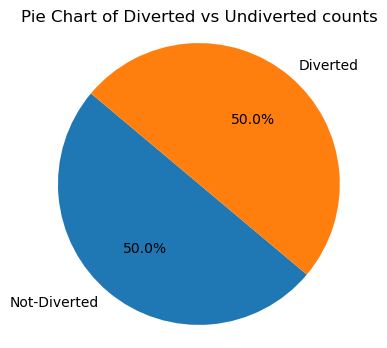

In [12]:
#verifying that the classes are balanced

diverted_counts = y_train_resampled_both['Diverted'].value_counts()
diverted_counts

plt.figure(figsize=(4, 4))
custom_labels = ['Not-Diverted', 'Diverted']
plt.pie(diverted_counts, labels = custom_labels, autopct='%1.1f%%', startangle=140)
plt.title('Pie Chart of Diverted vs Undiverted counts')
plt.axis('equal')  
plt.show()


In [13]:
y_resampled_array = y_train_resampled_both['Diverted'].to_numpy()

In [14]:
#Fitting X-train and Y-train to logistic regression pipeline with GridSearchCV

param_grid = {
'data_transformer__numerical__imputer__strategy': ['mean','median'],
'data_transformer__categorical__imputer__strategy': ['constant','most_frequent']
}
grid_lr = GridSearchCV(pipe_lr, param_grid=param_grid,error_score='raise')
grid_lr.fit(X_train_resampled_both, y_resampled_array);

In [15]:
#Generating Predicted Values

Y_predict_logistic = grid_lr.predict(X_test)

In [16]:
#Generating score

grid_lr.score(X_test, y_test)

0.6316356424996628

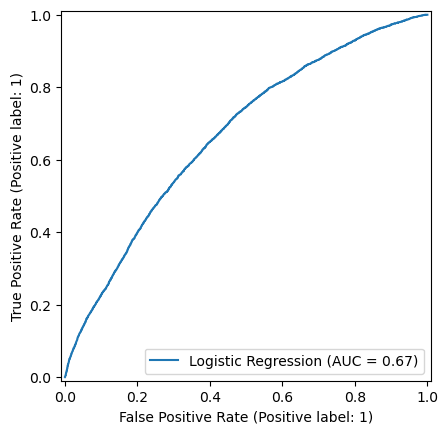

In [17]:
#Drawing the ROC curve

svc_disp = RocCurveDisplay.from_estimator(grid_lr, X_test, y_test, name = 'Logistic Regression')

In [18]:
#Generating classification report

upsampling_report = classification_report(y_test,Y_predict_logistic)
print(upsampling_report)

              precision    recall  f1-score   support

           0       1.00      0.63      0.77   2137839
           1       0.00      0.61      0.01      4738

    accuracy                           0.63   2142577
   macro avg       0.50      0.62      0.39   2142577
weighted avg       1.00      0.63      0.77   2142577



In [19]:
#Extracting the coeffitients

coefficients = grid_lr.best_estimator_.named_steps['pipe_lr'].coef_

numeric_feature_names = grid_lr.best_estimator_.named_steps['data_transformer'].named_transformers_['numerical'].named_steps['scaler'].get_feature_names_out(numerical_features)

categorical_feature_names = grid_lr.best_estimator_.named_steps['data_transformer'].named_transformers_['categorical'].named_steps['onehot'].get_feature_names_out(categorical_features)




coefficients_list =  coefficients.tolist()

numeric_feature_names_list = numeric_feature_names.tolist()

categorical_feature_names_list = categorical_feature_names.tolist()




In [20]:
combined_features_list = numeric_feature_names_list + categorical_feature_names_list

In [21]:
final_df = pd.DataFrame()
final_df['Features'] = combined_features_list
final_df['Co-effitient Values'] = coefficients_list[0]
final_df

,Features,Co-effitient Values
0,CRSDepTime,-0.067984
1,CRSArrTime,0.149891
2,Distance,0.510534
3,Destination_Latitude,0.040339
4,Destination_Longitude,0.089245
5,Origin_Latitude,0.033067
6,Origin_Longitude,0.108341
7,UniqueCarrier_AA,0.247368
8,UniqueCarrier_AQ,-0.913529
9,UniqueCarrier_AS,0.903231


In [22]:
#Calculating the overall coeffitient for each categorical feature by averaging the coeffitients 
#across all the classes of the variable


target_feature = 'UniqueCarrier'

# Finding the indices of the dummy variables corresponding to the target categorical feature
target_feature_indices = [i for i, name in enumerate(categorical_feature_names) if name.startswith(target_feature)]

# Extracting coefficients corresponding to the target feature
target_coefficients = coefficients[:, target_feature_indices]

# Calculating the common coefficient (e.g., average coefficient) across all dummy variables
common_coefficient_1 = np.mean(target_coefficients)




target_feature = 'Month'

# Finding the indices of the dummy variables corresponding to the target categorical feature
target_feature_indices = [i for i, name in enumerate(categorical_feature_names) if name.startswith(target_feature)]

# Extracting coefficients corresponding to the target feature
target_coefficients = coefficients[:, target_feature_indices]

# Calculating the common coefficient (e.g., average coefficient) across all dummy variables
common_coefficient_2 = np.mean(target_coefficients)





target_feature = 'DayOfWeek'

# Finding the indices of the dummy variables corresponding to the target categorical feature
target_feature_indices = [i for i, name in enumerate(categorical_feature_names) if name.startswith(target_feature)]

# Extracting coefficients corresponding to the target feature
target_coefficients = coefficients[:, target_feature_indices]

# Calculating the common coefficient (e.g., average coefficient) across all dummy variables
common_coefficient_3 = np.mean(target_coefficients)



print("Common coefficient for the UniqueCarrier feature:", common_coefficient_1)
print("Common coefficient for the Month feature:", common_coefficient_2)
print("Common coefficient for the DayOfWeek feature:", common_coefficient_3)





Common coefficient for the UniqueCarrier feature: 0.01608865069942963
Common coefficient for the Month feature: 0.026904711550226168
Common coefficient for the DayOfWeek feature: -0.027605486743999753


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]),
 [Text(0, 0, 'CRSDepTime'),
  Text(1, 0, 'CRSArrTime'),
  Text(2, 0, 'Distance'),
  Text(3, 0, 'Destination_Latitude'),
  Text(4, 0, 'Destination_Longitude'),
  Text(5, 0, 'Origin_Latitude'),
  Text(6, 0, 'Origin_Longitude'),
  Text(7, 0, 'UniqueCarrier_AA'),
  Text(8, 0, 'UniqueCarrier_AQ'),
  Text(9, 0, 'UniqueCarrier_AS'),
  Text(10, 0, 'UniqueCarrier_B6'),
  Text(11, 0, 'UniqueCarrier_CO'),
  Text(12, 0, 'UniqueCarrier_DL'),
  Text(13, 0, 'UniqueCarrier_EV'),
  Text(14, 0, 'UniqueCarrier_F9'),
  Text(15, 0, 'UniqueCarrier_FL'),
  Text(16, 0, 'UniqueCarrier_HA'),
  Text(17, 0, 'UniqueCarrier_MQ'),
  Text(18, 0, 'UniqueCarrier_NW'),
  Text(19, 0, 'UniqueCarrier_OH'),
  Text(20, 0, 'UniqueCarrier_OO'),
  Text(21, 0, 'UniqueCarrier_TZ'),
  Text(22, 0, 'UniqueCarrier_UA'),
  Text(

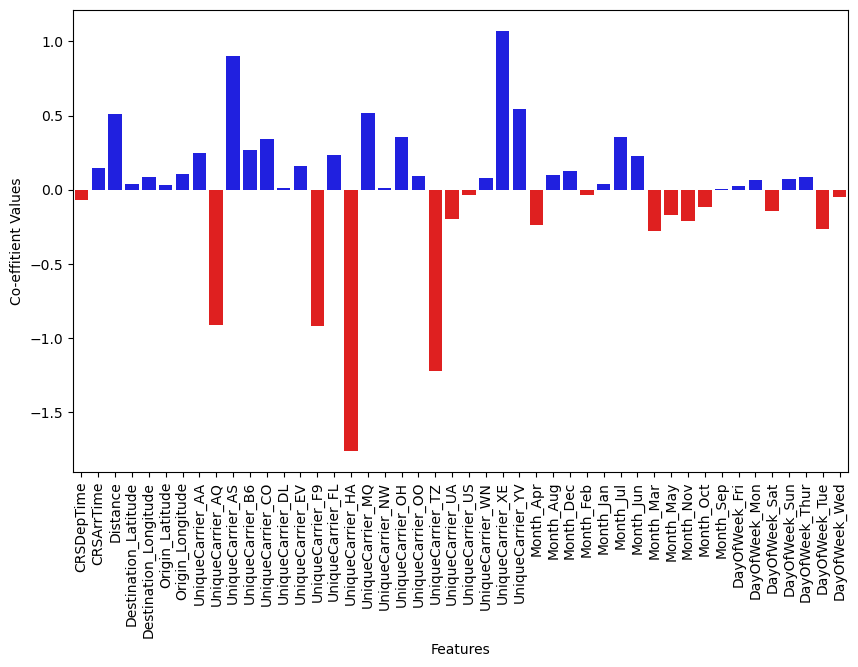

In [23]:
#Visualizing the coeffitients

positive_color = 'blue'
negative_color = 'red'

def color_palette(values):
    return [positive_color if val >= 0 else negative_color for val in values]




plt.figure(figsize=(10, 6))
sns.barplot(x='Features', y='Co-effitient Values', data=final_df, palette=color_palette(final_df['Co-effitient Values']),
            width = 0.8 )
plt.xticks(rotation=90)

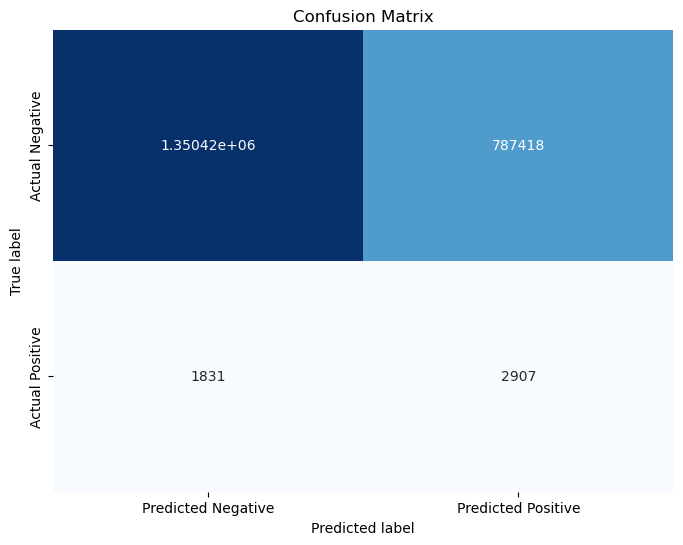

In [24]:
#Plotting the confusion matrix

cm = confusion_matrix(y_test, Y_predict_logistic)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g', cbar=False, 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()
